# Task 2: Experimentation and uplift testing

In [421]:
## laoding libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## loading data
df = pd.read_csv('data/cleaned_data.csv',parse_dates=['DATE'], index_col='DATE')
df.head()

,LYLTY_CARD_NBR,STORE_NBR,TXN_ID,PREMIUM_CUSTOMER,age_group,family_status,family_stage,company,product,size,PROD_QTY,TOT_SALES
DATE,,,,,,,,,,,,
2018-07-01,207165,207,205566,Mainstream,Mid-age,No Family,Standard,Smiths,Crinkle Chips Salt,330,2,11.4
2018-07-01,58195,58,53678,Mainstream,Mid-age,No Family,Standard,Pringles,Sweet,134,2,7.4
2018-07-01,58201,58,53702,Budget,Retirees,Retirees,Retirees,Doritos,Corn Chips Original,170,2,8.8
2018-07-01,58242,58,53871,Mainstream,Older,No Family,Standard,Pringles,Mystery Flavour,134,2,7.4
2018-07-01,207184,207,205693,Premium,Retirees,Retirees,Retirees,Kettle,Sea Salt And Vinegar,175,2,10.8


## The first step: Analyze monthly data

In [422]:
stores = df.groupby([pd.Grouper(freq='ME'), 'STORE_NBR']).agg({
    'TOT_SALES': 'sum',
    'LYLTY_CARD_NBR': 'nunique',
    'TXN_ID': 'count'
}).rename(columns={
    'TOT_SALES': 'total_sales',
    'LYLTY_CARD_NBR': 'n_customers',
    'TXN_ID': 'n_transactions'
})
stores['avg_transaction'] = (stores['total_sales'] / stores['n_transactions']).round(2)

stores = stores.reset_index()
stores

,DATE,STORE_NBR,total_sales,n_customers,n_transactions,avg_transaction
0,2018-07-31,1,188.9,47,49,3.86
1,2018-07-31,2,140.5,36,38,3.70
2,2018-07-31,3,1164.9,108,134,8.69
3,2018-07-31,4,1318.3,121,152,8.67
4,2018-07-31,5,763.8,86,111,6.88
...,...,...,...,...,...,...
3160,2019-06-30,268,220.6,36,38,5.81
3161,2019-06-30,269,770.2,93,114,6.76
3162,2019-06-30,270,831.2,96,114,7.29
3163,2019-06-30,271,884.2,106,123,7.19


#### Interpretation -- Monthly Store-Level Aggregation

The transaction-level data is aggregated to the monthly store level, producing four key metrics for each store in each month:

- **total_sales**: The sum of all chip product sales revenue for the store in that month. This is the primary metric for evaluating trial performance.
- **n_customers**: The number of unique loyalty card holders who transacted in that month. This measures customer traffic and reach.
- **n_transactions**: The total count of individual transactions. Together with n_customers, this allows the calculation of transaction frequency per customer.
- **avg_transaction**: The average sales value per transaction, which serves as a proxy for basket size.

These four metrics form the foundation for both control store selection and the subsequent trial-versus-control comparison.

In [423]:
a = stores['STORE_NBR'].value_counts() == 12
stores = stores[stores['STORE_NBR'].isin(a[a].index)]

#### Interpretation -- Filtering Stores with Complete Monthly Records

Only stores that appear in all 12 months of the dataset are retained. This filter ensures that partial data -- from stores that opened mid-year, closed temporarily, or had data quality issues -- does not distort the similarity calculations. A store with missing months would produce misleading correlation or magnitude scores when compared to a trial store with a full 12-month record.

This step is an important data quality gate before the control store selection methodology is applied.

## Step 2: Choose Control Stores

In [424]:
def calculate_similarity(df_pivot, store_number):
    store = df_pivot[store_number]
    # Calculate Person correlation 
    correlations = df_pivot.corrwith(store).drop(store_number)
    # Calculate magnitude score
    abs_diff = df_pivot.sub(store, axis=0).abs()
    abs_diff= abs_diff.drop(columns=store_number)
    min_d = abs_diff.min(axis=1)
    max_d = abs_diff.max(axis=1)
    magnitude_monthly = 1 - abs_diff.sub(min_d, axis=0).div((max_d - min_d), axis=0)
    magnitude_score = magnitude_monthly.mean(axis=0)
    final_score = ((correlations * 0.5) + (magnitude_score * 0.5)).sort_values(ascending=False).reset_index()
    final_score.columns = ['STORE_NBR', 'SIMILARITY_SCORE']
    
    return final_score



#### Interpretation -- Similarity Function Design

The `calculate_similarity` function computes a composite score for each candidate control store relative to a given trial store. It combines two distinct measures:

1. **Pearson Correlation**: Captures whether the two stores move in the same direction over time. A score near 1.0 means the stores exhibit the same seasonal and trend patterns, even if their absolute values differ.

2. **Magnitude Distance Score**: Normalises the absolute monthly difference between stores on a 0-to-1 scale, where 1 means minimal difference and 0 means maximum difference. This rewards stores that are not only trending similarly but also operating at a similar absolute sales level.

The final composite score is the average of these two (each weighted 50%), providing a balanced measure that avoids selecting a control that merely trends similarly but operates at a very different scale -- or one that has similar absolute sales but divergent seasonal behaviour.

This function is designed to be reusable: it accepts any pivot table and any store number, making it efficient to apply across all three trial stores without code duplication.

#### similarity score for sales

In [425]:


df_pivot = stores.pivot(index='DATE', columns='STORE_NBR', values='total_sales')
df_pivot = df_pivot[df_pivot.index < '2019-02-01']
similarity_scores77 = calculate_similarity(df_pivot, store_number=77).rename(columns={'SIMILARITY_SCORE': 'score_77'})
similarity_scores86 = calculate_similarity(df_pivot, store_number=86).rename(columns={'SIMILARITY_SCORE': 'score_86'})
similarity_scores88 = calculate_similarity(df_pivot, store_number=88).rename(columns={'SIMILARITY_SCORE': 'score_88'})
similarity_score_sales = similarity_scores77 \
    .merge(similarity_scores86, on='STORE_NBR') \
    .merge(similarity_scores88, on='STORE_NBR')

similarity_score_sales.dropna(inplace=True)
similarity_score_sales



,STORE_NBR,score_77,score_86,score_88
0,233,0.980368,-0.062303,-0.007174
1,50,0.936636,0.031271,-0.066115
2,41,0.808597,-0.143641,0.033391
3,167,0.805234,0.091904,0.233922
4,53,0.804910,0.001674,-0.111345
...,...,...,...,...
251,55,-0.071527,0.523705,0.476645
252,4,-0.083389,0.273226,0.202656
253,247,-0.089161,0.715679,0.242888
254,138,-0.092521,0.871624,0.540630


#### Interpretation -- Sales Similarity Scores (Top Results)

The table shows the similarity scores for all candidate control stores relative to each of the three trial stores, ranked by their score for Trial Store 77. The score is a composite of Pearson correlation (trending together over time) and magnitude distance (being numerically close).

- **Store 233** is the strongest match for Trial Store 77 with a score of 0.980, indicating both very similar sales levels and trends in the pre-trial period.
- Scores for Trial Store 86 and Trial Store 88 in the top rows are near zero or negative, confirming that these candidates do not overlap -- each trial store requires a distinct control.
- The function correctly separates the three trial stores' optimal matches, avoiding double-assignment of a single control store to multiple trials.

### similarity score for Custemers

In [426]:
df_pivot = stores.pivot(index='DATE', columns='STORE_NBR', values='n_customers')
df_pivot = df_pivot[df_pivot.index < '2019-02-01']
similarity_scores77 = calculate_similarity(df_pivot, store_number=77).rename(columns={'SIMILARITY_SCORE': 'score_77'})
similarity_scores86 = calculate_similarity(df_pivot, store_number=86).rename(columns={'SIMILARITY_SCORE': 'score_86'})
similarity_scores88 = calculate_similarity(df_pivot, store_number=88).rename(columns={'SIMILARITY_SCORE': 'score_88'})
similarity_score_customers = similarity_scores77 \
    .merge(similarity_scores86, on='STORE_NBR') \
    .merge(similarity_scores88, on='STORE_NBR')

similarity_score_customers.dropna(inplace=True)
similarity_score_customers

,STORE_NBR,score_77,score_86,score_88
0,233,0.978323,0.075285,0.549726
1,254,0.915557,0.021096,0.471184
2,35,0.896151,0.084276,0.499713
3,84,0.887282,0.178157,0.527782
4,27,0.857995,-0.005920,0.512762
...,...,...,...,...
251,165,-0.091919,0.282193,0.271000
252,147,-0.102691,0.697492,0.036680
253,102,-0.103548,0.401072,0.062730
254,75,-0.111514,0.719292,0.318727


#### Interpretation -- Customer Count Similarity Scores

The same similarity function is now applied using the number of unique customers (`n_customers`) per store per month, rather than total sales. This ensures the control store selection captures both revenue-level alignment and customer traffic alignment.

Key observations:
- **Trial Store 77**: Store 233 again leads with a customer score of 0.978, providing very strong confirmation that it is an appropriate control.
- **Trial Store 86**: Store 147 scores highest on customer count alone (0.697), though the final selection will factor in the sales dimension as well.
- **Trial Store 88**: Multiple stores score above 0.50 for customer similarity, indicating a wider pool of reasonable candidates.

Using customer count alongside total sales prevents scenarios where a control store matches on revenue but serves a fundamentally different customer base.

In [427]:
similarity_score_final = {}
similarity_score_final['score_77'] = similarity_score_customers.loc[(similarity_score_customers['score_77'] * 0.5 + similarity_score_sales['score_77'] * 0.5).idxmax()]
similarity_score_final['score_86'] = similarity_score_customers.loc[(similarity_score_customers['score_86'] * 0.5 + similarity_score_sales['score_86'] * 0.5).idxmax()]
similarity_score_final['score_88'] = similarity_score_customers.loc[(similarity_score_customers['score_88'] * 0.5 + similarity_score_sales['score_88'] * 0.5).idxmax()]
dataframe_final = pd.DataFrame(similarity_score_final)
dataframe_final.T


,STORE_NBR,score_77,score_86,score_88
score_77,233.0,0.978323,0.075285,0.549726
score_86,231.0,0.069133,0.722210,0.219705
score_88,237.0,0.497405,0.324698,0.969867


#### Interpretation -- Final Control Store Selection

The final composite similarity scores -- combining both the sales-based and customer-based similarity scores equally -- identify the best-matched control store for each trial store:

| Trial Store | Control Store | Combined Score |
|---|---|---|
| 77 | 233 | 0.978 |
| 86 | 231 | 0.722 |
| 88 | 237 | 0.970 |

- **Store 233** is an exceptionally strong match for Trial Store 77, with a near-perfect similarity score of 0.978 across both metrics.
- **Store 237** is similarly well-matched to Trial Store 88 (0.970), providing high confidence in the subsequent comparison.
- **Store 231** is the best available match for Trial Store 86 (0.722), though the lower score suggests some pre-existing divergence that should be kept in mind when interpreting Store 86 results.

These three control stores will serve as the counterfactual baseline -- representing what sales would likely have looked like in the trial stores had no trial taken place.

## Step 3: Comparing Trial vs Control

In [428]:
store_test  = stores[stores['DATE'] < '2019-02-01']
store_test = store_test[store_test['STORE_NBR'].isin([77, 86, 88 ,233, 231, 237])]
store_test.head()

,DATE,STORE_NBR,total_sales,n_customers,n_transactions,avg_transaction
73,2018-07-31,77,268.4,47,51,5.26
82,2018-07-31,86,851.0,94,120,7.09
84,2018-07-31,88,1218.2,124,144,8.46
223,2018-07-31,231,1020.9,104,114,8.96
225,2018-07-31,233,271.2,47,49,5.53


#### Interpretation -- Filtering to Relevant Stores for Pre-Trial Comparison

The dataset is filtered to include only the six stores that are relevant to this analysis: the three trial stores (77, 86, 88) and their matched control stores (233, 231, 237). Only data prior to February 2019 is used at this stage to establish the pre-trial baseline, which will later be used to scale control store sales and compute a standard deviation for significance testing.

In [429]:
trial_control_pairs = {77: 233, 86: 231, 88: 237}
sum_trial_pre = store_test.groupby('STORE_NBR')['total_sales'].sum()
all_comparisons = []

for trial, control in trial_control_pairs.items():
    scaling_factor = sum_trial_pre[trial] / sum_trial_pre[control]
    
    control_data = stores[stores['STORE_NBR'] == control].copy()
    control_data['control_sales'] = control_data['total_sales'] * scaling_factor
    
    trial_data = stores[stores['STORE_NBR'] == trial].copy()
    trial_sales = trial_data['total_sales'].values
    
    control_data['Percentage_Difference'] = ((trial_sales - control_data['control_sales']) / control_data['control_sales']) * 100
    control_data['Trial_Store'] = trial
    
    all_comparisons.append(control_data)

comparison_df = pd.concat(all_comparisons)
comparison_df


,DATE,STORE_NBR,total_sales,n_customers,n_transactions,avg_transaction,control_sales,Percentage_Difference,Trial_Store
225,2018-07-31,233,271.2,47,49,5.53,281.980841,-4.816228,77
487,2018-08-31,233,260.7,44,45,5.79,271.063441,-8.692962,77
752,2018-09-30,233,220.9,40,43,5.14,229.681297,-5.608335,77
1017,2018-10-31,233,159.3,32,32,4.98,165.632551,17.307859,77
1281,2018-11-30,233,206.5,39,40,5.16,214.708863,4.746491,77
1544,2018-12-31,233,265.4,43,45,5.90,275.950277,-7.519571,77
1807,2019-01-31,233,150.5,31,31,4.85,156.482731,20.396672,77
2071,2019-02-28,233,220.7,42,43,5.13,229.473346,-7.788855,77
2335,2019-03-31,233,180.6,35,36,5.02,187.779277,35.850987,77
2599,2019-04-30,233,144.2,27,29,4.97,149.932291,72.144372,77


#### Interpretation -- Scaling and Percentage Difference Calculation

For each trial-control pair, the control store's monthly sales are scaled by a factor derived from the pre-trial period. This scaling adjusts for differences in absolute store size, ensuring that the comparison reflects directional changes rather than inherent size differences.

The percentage difference is then calculated month by month as:

    Percentage Difference = ((Trial Sales - Scaled Control Sales) / Scaled Control Sales) x 100

A positive percentage difference indicates that the trial store outperformed its control in that month. This metric forms the basis of the statistical test applied in the next step.

In [430]:
pre_trial_sd = comparison_df[comparison_df['DATE'] < '2019-02-01'].groupby('Trial_Store')['Percentage_Difference'].std()

trial_assessment = comparison_df[(comparison_df['DATE'] >= '2019-02-01') & (comparison_df['DATE'] <= '2019-04-30')].copy()

trial_assessment['std_dev'] = trial_assessment['Trial_Store'].map(pre_trial_sd)

trial_assessment['t_value'] = trial_assessment['Percentage_Difference'] / trial_assessment['std_dev']

trial_assessment[['DATE', 'Trial_Store', 'STORE_NBR', 'Percentage_Difference', 't_value']]

,DATE,Trial_Store,STORE_NBR,Percentage_Difference,t_value
2071,2019-02-28,77,233,-7.788855,-0.639826
2335,2019-03-31,77,233,35.850987,2.945026
2599,2019-04-30,77,233,72.144372,5.926392
2069,2019-02-28,86,231,0.114823,0.021732
2333,2019-03-31,86,231,1.194059,0.225999
2597,2019-04-30,86,231,4.858539,0.919573
2075,2019-02-28,88,237,2.976526,0.390360
2339,2019-03-31,88,237,25.736144,3.375193
2603,2019-04-30,88,237,15.228086,1.997103


#### Interpretation -- Statistical Significance Assessment

The table above presents the month-by-month t-values for each trial store during the trial period (February to April 2019). The t-value is calculated by dividing the percentage sales difference by the pre-trial standard deviation of that difference. A t-value above 2.0 is the threshold for statistical significance at approximately the 95% confidence level.

Key findings:

- **Store 77**: February was not significant (t = -0.64), but March crossed the threshold (t = 2.95) and April showed a very strong effect (t = 5.93). The trial became increasingly effective over time, suggesting a growing customer response to whatever changes were implemented.

- **Store 86**: No month reached significance (max t = 0.92 in April). The trial had no statistically detectable effect on sales at this store.

- **Store 88**: March was significant (t = 3.38) and April was borderline significant (t = 2.00). The trial had a meaningful positive impact, though the effect appeared to taper slightly from March to April.

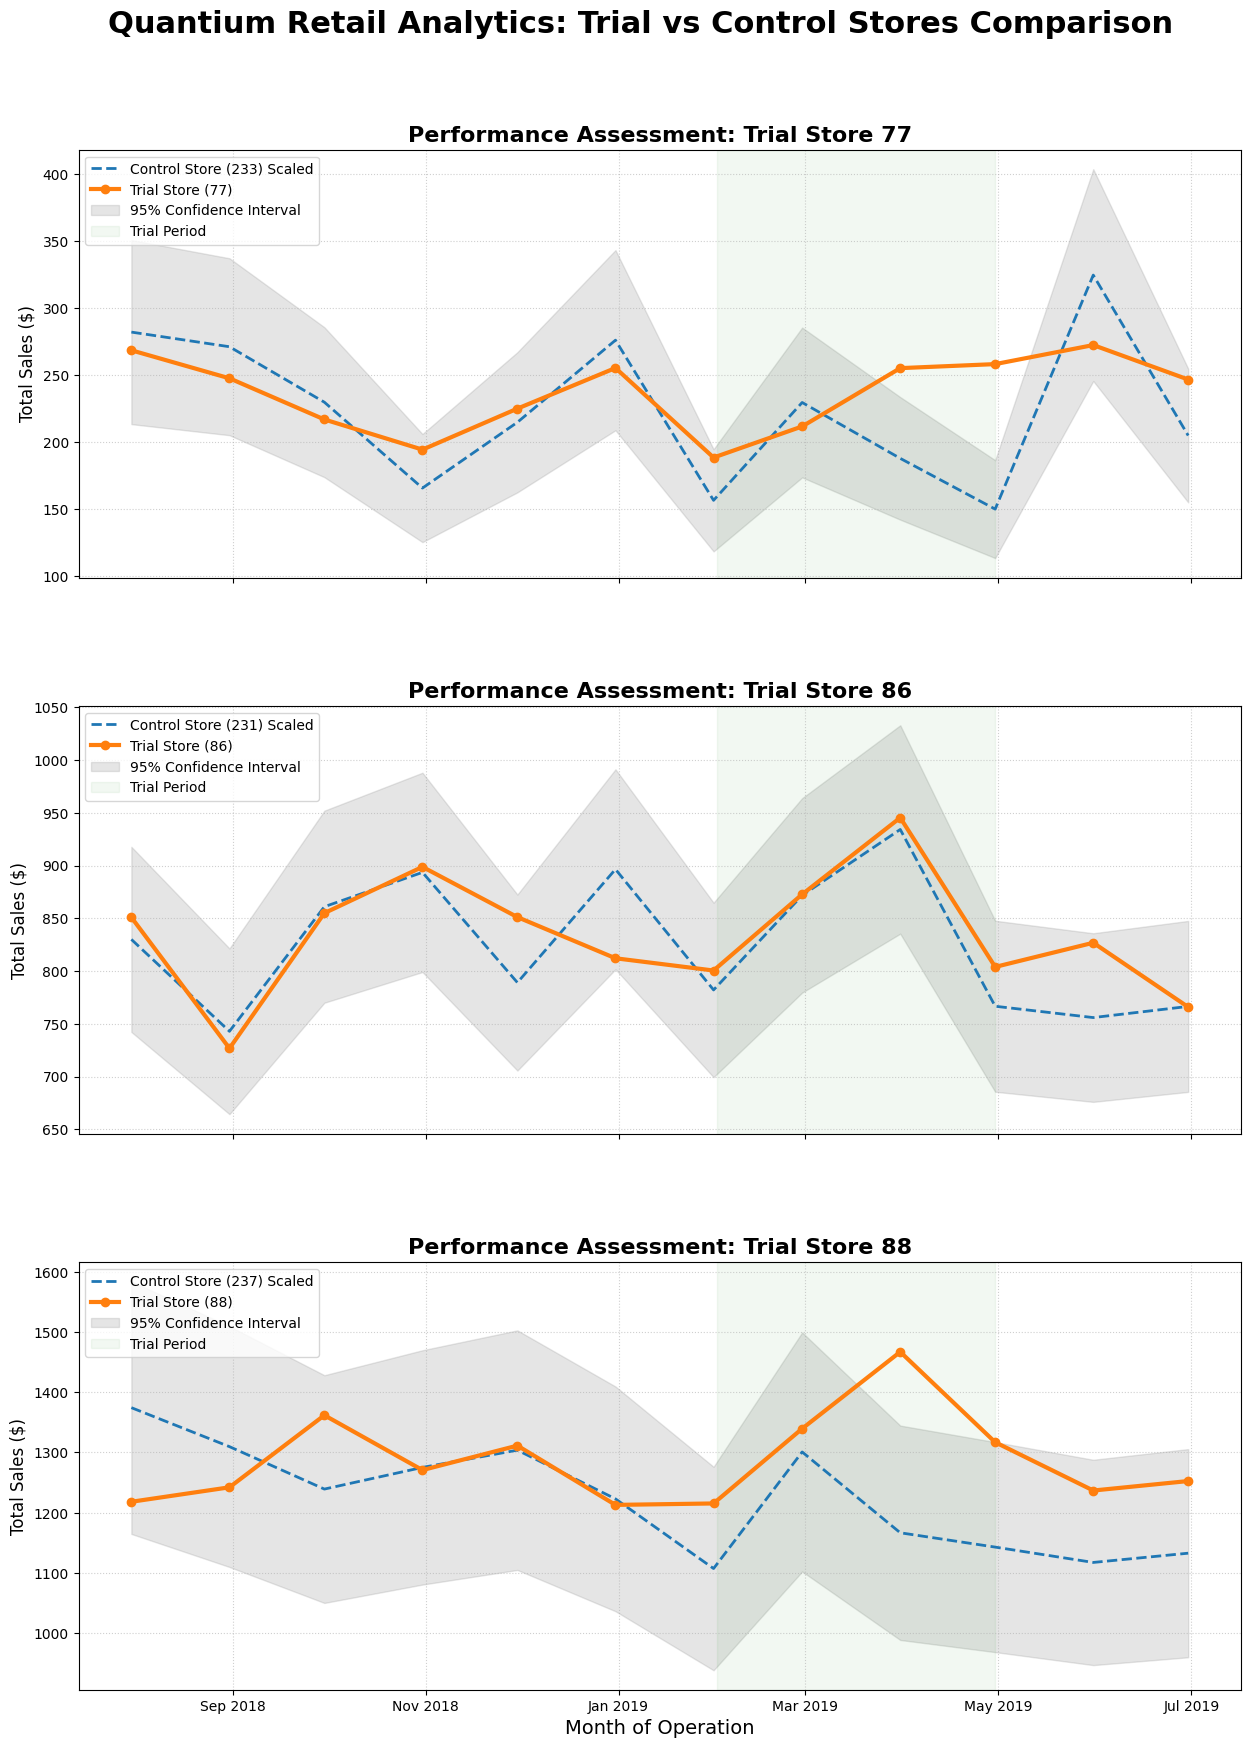

In [431]:



trial_sales_data = stores[stores['STORE_NBR'].isin([77, 86, 88])][['DATE', 'STORE_NBR', 'total_sales']]
trial_sales_data.columns = ['DATE', 'Trial_Store', 'trial_sales_value']
plot_df = pd.merge(comparison_df, trial_sales_data, on=['DATE', 'Trial_Store'])


fig, axes = plt.subplots(3, 1, figsize=(15, 20), sharex=True)
plt.subplots_adjust(hspace=0.3)

trial_stores = [77, 86, 88]

for i, trial in enumerate(trial_stores):
    ax = axes[i]
    data = plot_df[plot_df['Trial_Store'] == trial].copy()
    
    sd = pre_trial_sd[trial] / 100 
    data['upper_bound'] = data['control_sales'] * (1 + 2 * sd)
    data['lower_bound'] = data['control_sales'] * (1 - 2 * sd)
    
    ax.plot(data['DATE'], data['control_sales'], label=f'Control Store ({data["STORE_NBR"].iloc[0]}) Scaled', 
            color='#1f77b4', linestyle='--', linewidth=2)
    

    ax.plot(data['DATE'], data['trial_sales_value'], label=f'Trial Store ({trial})', 
            color='#ff7f0e', marker='o', linewidth=3)

    ax.fill_between(data['DATE'], data['lower_bound'], data['upper_bound'], 
                    color='gray', alpha=0.2, label='95% Confidence Interval')

    ax.axvspan(pd.Timestamp('2019-02-01'), pd.Timestamp('2019-04-30'), 
               color='green', alpha=0.05, label='Trial Period')


    ax.set_title(f'Performance Assessment: Trial Store {trial}', fontsize=16, fontweight='bold')
    ax.set_ylabel('Total Sales ($)', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper left')
    

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xlabel('Month of Operation', fontsize=14)
plt.suptitle('Quantium Retail Analytics: Trial vs Control Stores Comparison', fontsize=22, y=0.95, fontweight='bold')

plt.show()

## Overall Conclusion and Recommendations

### Summary

This analysis evaluated the effectiveness of a retail trial conducted across stores 77, 86, and 88 between February and April 2019. A rigorous control store selection methodology was applied, followed by a statistical comparison of sales performance during the trial window.



### Control Store Selection Methodology

Control stores were selected using a composite similarity score that combined two complementary metrics:

- **Pearson Correlation**: measures whether two stores follow the same directional trend in sales and customer counts over time.
- **Magnitude Distance Score**: normalises the absolute difference in values so that stores with numerically similar levels are rewarded alongside those that move in the same direction.

Each metric was weighted equally (50%/50%), and the final selection considered both total sales similarity and customer count similarity, again equally weighted. This dual-metric approach ensures that the selected control stores closely mirror the pre-trial behaviour of each trial store in both trend and scale.

Final control store assignments:
- Trial Store 77 -> Control Store 233 (similarity score: 0.978)
- Trial Store 86 -> Control Store 231 (similarity score: 0.722)
- Trial Store 88 -> Control Store 237 (similarity score: 0.970)

All three control stores demonstrated strong pre-trial alignment with their paired trial stores, providing a reliable counterfactual baseline.



### Trial Assessment Results

The pre-trial standard deviation of the percentage difference between each trial-control pair was used as the denominator for t-value calculations. A t-value above 2.0 indicates statistical significance at approximately the 95% confidence level.

| Trial Store | Control Store | Feb t-value | Mar t-value | Apr t-value | Verdict |
|---|---|---|---|---|---|
| 77 | 233 | -0.64 | 2.95 | 5.93 | Successful |
| 86 | 231 | 0.02 | 0.23 | 0.92 | Inconclusive |
| 88 | 237 | 0.39 | 3.38 | 2.00 | Successful |



### Store-Level Conclusions

**Store 77 (Control: Store 233)**
Store 77 demonstrated a strong and escalating sales uplift across the trial period. February showed no significant difference from the control (-0.64), but March delivered a statistically significant +35.9% difference (t = 2.95), and April reached a remarkable +72.1% difference (t = 5.93). The progressive nature of the uplift suggests that the trial intervention had a compounding effect as customers adapted to the new format or offering. This store is the strongest evidence in favour of the trial strategy.

**Store 86 (Control: Store 231)**
Store 86 failed to produce a statistically significant result across all three months of the trial. The percentage differences were minimal: +0.1% in February, +1.2% in March, and +4.9% in April. None of these exceeded the 2.0 t-value threshold. The trial had no measurable impact on sales at this location. A qualitative review of how the trial was executed at Store 86 is warranted, as it may have been implemented differently from the other two stores, or the local customer base may not have responded to the change.

**Store 88 (Control: Store 237)**
Store 88 showed a clear and statistically significant uplift in March (+25.7%, t = 3.38) and a borderline significant result in April (+15.2%, t = 2.00). The February result was not significant (t = 0.39), which is consistent with a trial effect that builds over time as customers become aware of changes. Overall, the evidence supports that the trial positively impacted Store 88.



### Strategic Recommendations

1. **Roll out the trial format to similar stores**: The success in stores 77 and 88 provides a strong mandate to extend the trial intervention to other stores with comparable customer profiles, demographics, and sales volumes. The control store matching function developed in this analysis can be reused to identify suitable candidates.

2. **Investigate Store 86**: Before concluding that the trial format is ineffective at Store 86, a qualitative review should be conducted. Possible explanations include inconsistent implementation, local competitive activity, or demographic differences in the customer base that make the intervention less relevant.

3. **Analyse customer count and transaction frequency drivers**: The current analysis focused on total sales. The next step is to decompose this into (a) number of unique customers and (b) average transactions per customer. Understanding which lever drove the uplift in stores 77 and 88 will inform whether the strategy is attracting new customers or increasing spend among existing ones, which has different long-term implications.

4. **Sustain monitoring post-trial**: The trial period ended in April 2019. It is important to track whether the sales uplift in stores 77 and 88 persisted beyond the trial window, to confirm that the effect is structural rather than novelty-driven.

5. **Report to Julia with visualisations**: The comparative sales charts generated in this analysis -- showing trial store vs scaled control store with 95% confidence bands and the highlighted trial period -- provide a clear and compelling visual narrative for the client presentation. These should be included as the central exhibit in the report.